# Agriculture commodity portfolio: grains, oilseeds, livestock, and oils

This notebook uses the maintained Barchart agricultural catalog and the
no-login public historical route. It downloads the current first-nearby
contract for each catalog root, preserves the source contract, and creates
transparent rebased price paths.

The comparison is not a synthetic continuous futures series. Every line is
one fixed contract selected by Barchart's *1 shortcut at run time. Rebasing
puts different units and currencies on a common index scale; it does not
create a tradable portfolio return.



In [1]:
from pathlib import Path
import sys

candidate_roots = [Path.cwd(), *Path.cwd().parents]
repo_root = next(
    (candidate for candidate in candidate_roots if (candidate / "Barchart").is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError("Run this demo from a checkout containing the Barchart folder.")
sys.path.insert(0, str(repo_root))

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from Barchart import (
    BarchartHistoricalData,
    agricultural_catalog,
    catalog_frame,
    rebase_frame,
    rebase_many,
)

START_DATE = "2024-01-01"
END_DATE = None
CATEGORY_WEIGHTS = {
    "grains": 0.35,
    "oilseeds": 0.35,
    "livestock": 0.20,
    "vegetable_oils": 0.10,
}

client = BarchartHistoricalData()
catalog = agricultural_catalog(comparison_only=True)
catalog_by_root = {item.root: item for item in catalog}

navy = "#13233A"
gold = "#F4B942"
green = "#69B578"
sky = "#73B7D8"
red = "#D95D5D"
muted = "#AEB9C6"



## 1. Catalog and market coverage

The catalog includes CBOT/CME grains and oilseeds, ICE Canada canola,
Euronext Matif wheat and rapeseed, CME livestock, and Barchart's
palm-oil-related roots. The metadata table is the source of truth for roots,
venues, units, contract months, and nearby shortcuts.



In [2]:
display(catalog_frame())
print("Data route: Barchart public historical endpoint")
print("Credentials used: none")



,name,root,category,venue,exchange_symbol,units,contract_months,notes,comparison_default,front_shortcut
0,Corn,ZC,grains,CBOT,ZC,"5,000 bushels",H K N U Z,,True,ZC*1
1,Chicago SRW Wheat,ZW,grains,CBOT,ZW,"5,000 bushels",H K N U Z,,True,ZW*1
2,KC HRW Wheat,KE,grains,CBOT,KE,"5,000 bushels",H K N U Z,,True,KE*1
3,Spring Wheat,MW,grains,MIAX/MWE,MW,"5,000 bushels",H K N U Z,,True,MW*1
4,Hard Red Spring Wheat,KW,grains,CME,KW,"5,000 bushels",H K N U Z,,True,KW*1
5,Oats,ZO,grains,CBOT,ZO,"5,000 bushels",H K N U Z,,True,ZO*1
6,Rough Rice,ZR,grains,CBOT,ZR,"2,000 hundredweight",F H K N U X,,True,ZR*1
7,Euronext Milling Wheat,ML,grains,Euronext Matif,EBM,50 metric tonnes,H K U Z,,True,ML*1
8,Soybeans,ZS,oilseeds,CBOT,ZS,"5,000 bushels",F H K N Q U X,,True,ZS*1
9,Soybean Meal,ZM,oilseeds,CBOT,ZM,100 short tons,F H K N Q U V Z,,True,ZM*1


Data route: Barchart public historical endpoint
Credentials used: none


## 2. Download the current first-nearby contracts

Barchart's *1 shortcut is resolved when the notebook runs. The downloaded
rows retain the actual contract symbol, so each comparison remains
auditable. A failed symbol is reported rather than silently dropped.



In [3]:
comparison_frames = {}
comparison_rows = []
failed_rows = []

for item in catalog:
    shortcut = item.barchart_symbol()
    try:
        front = client.history(
            shortcut,
            start_date=START_DATE,
            end_date=END_DATE,
            out="df",
        )
        if front.empty or "close" not in front.columns:
            raise ValueError("empty history or missing close column")

        front = front.copy()
        front["date"] = pd.to_datetime(front["date"], errors="coerce")
        front["close"] = pd.to_numeric(front["close"], errors="coerce")
        front = (
            front.dropna(subset=["date", "close"])
            .sort_values("date")
            .drop_duplicates(subset=["date"], keep="last")
            .reset_index(drop=True)
        )
        actual_symbols = (
            sorted(front["symbol"].dropna().astype(str).unique())
            if "symbol" in front.columns
            else []
        )
        actual_symbol = actual_symbols[-1] if actual_symbols else shortcut
        normalized = rebase_frame(front)
        comparison_frames[item.root] = normalized
        valid = normalized.loc[normalized["index_100"].notna()]
        comparison_rows.append(
            {
                "root": item.root,
                "name": item.name,
                "category": item.category,
                "front_contract": actual_symbol,
                "venue": item.venue,
                "units": item.units,
                "first_date": valid["date"].iat[0].date(),
                "last_date": valid["date"].iat[-1].date(),
                "rows": len(valid),
            }
        )
    except Exception as exc:
        failed_rows.append(
            {
                "root": item.root,
                "name": item.name,
                "shortcut": shortcut,
                "error": f"{type(exc).__name__}: {exc}",
            }
        )

if not comparison_frames:
    raise RuntimeError("No agricultural front-contract histories were returned.")

front_contracts = pd.DataFrame(comparison_rows).sort_values(["category", "root"])
display(front_contracts.reset_index(drop=True))
if failed_rows:
    display(pd.DataFrame(failed_rows))



,root,name,category,front_contract,venue,units,first_date,last_date,rows
0,KE,KC HRW Wheat,grains,KEU26,CBOT,"5,000 bushels",2024-07-12,2026-08-21,531
1,KW,Hard Red Spring Wheat,grains,KWU26,CME,"5,000 bushels",2025-04-11,2026-08-21,333
2,ML,Euronext Milling Wheat,grains,MLU26,Euronext Matif,50 metric tonnes,2024-01-02,2026-08-21,674
3,MW,Spring Wheat,grains,MWU26,MIAX/MWE,"5,000 bushels",2025-02-05,2026-08-21,388
4,ZC,Corn,grains,ZCU26,CBOT,"5,000 bushels",2024-01-02,2026-08-21,663
5,ZO,Oats,grains,ZOU26,CBOT,"5,000 bushels",2024-01-02,2026-08-21,663
6,ZR,Rough Rice,grains,ZRU26,CBOT,"2,000 hundredweight",2025-07-14,2026-08-21,280
7,ZW,Chicago SRW Wheat,grains,ZWU26,CBOT,"5,000 bushels",2024-07-12,2026-08-21,531
8,GF,Feeder Cattle,livestock,GFQ26,CME,"50,000 pounds",2025-06-06,2026-08-21,304
9,HE,Lean Hogs,livestock,HEV26,CME,"40,000 pounds",2025-05-14,2026-08-21,320


## 3. Tidy rebased price paths

rebase_many produces a long table suitable for downstream analytics. The
first observation of every fixed contract is 100. Missing dates are left
missing; the notebook does not interpolate prices across non-trading days.



In [4]:
indexed_history = pd.concat(
    {
        root: frame.set_index("date")["index_100"]
        for root, frame in comparison_frames.items()
    },
    axis=1,
).sort_index()

rebased_long = rebase_many(comparison_frames)
display(rebased_long.head(12))



,date,series,index_100
0,2024-01-02,ZC,100.000000
1,2024-01-03,ZC,100.000000
2,2024-01-04,ZC,99.848332
3,2024-01-05,ZC,98.382204
4,2024-01-08,ZC,97.927199
5,2024-01-09,ZC,98.736097
6,2024-01-10,ZC,98.584429
7,2024-01-11,ZC,98.230536
8,2024-01-12,ZC,97.371082
9,2024-01-16,ZC,96.511628


## 4. Market-group comparison



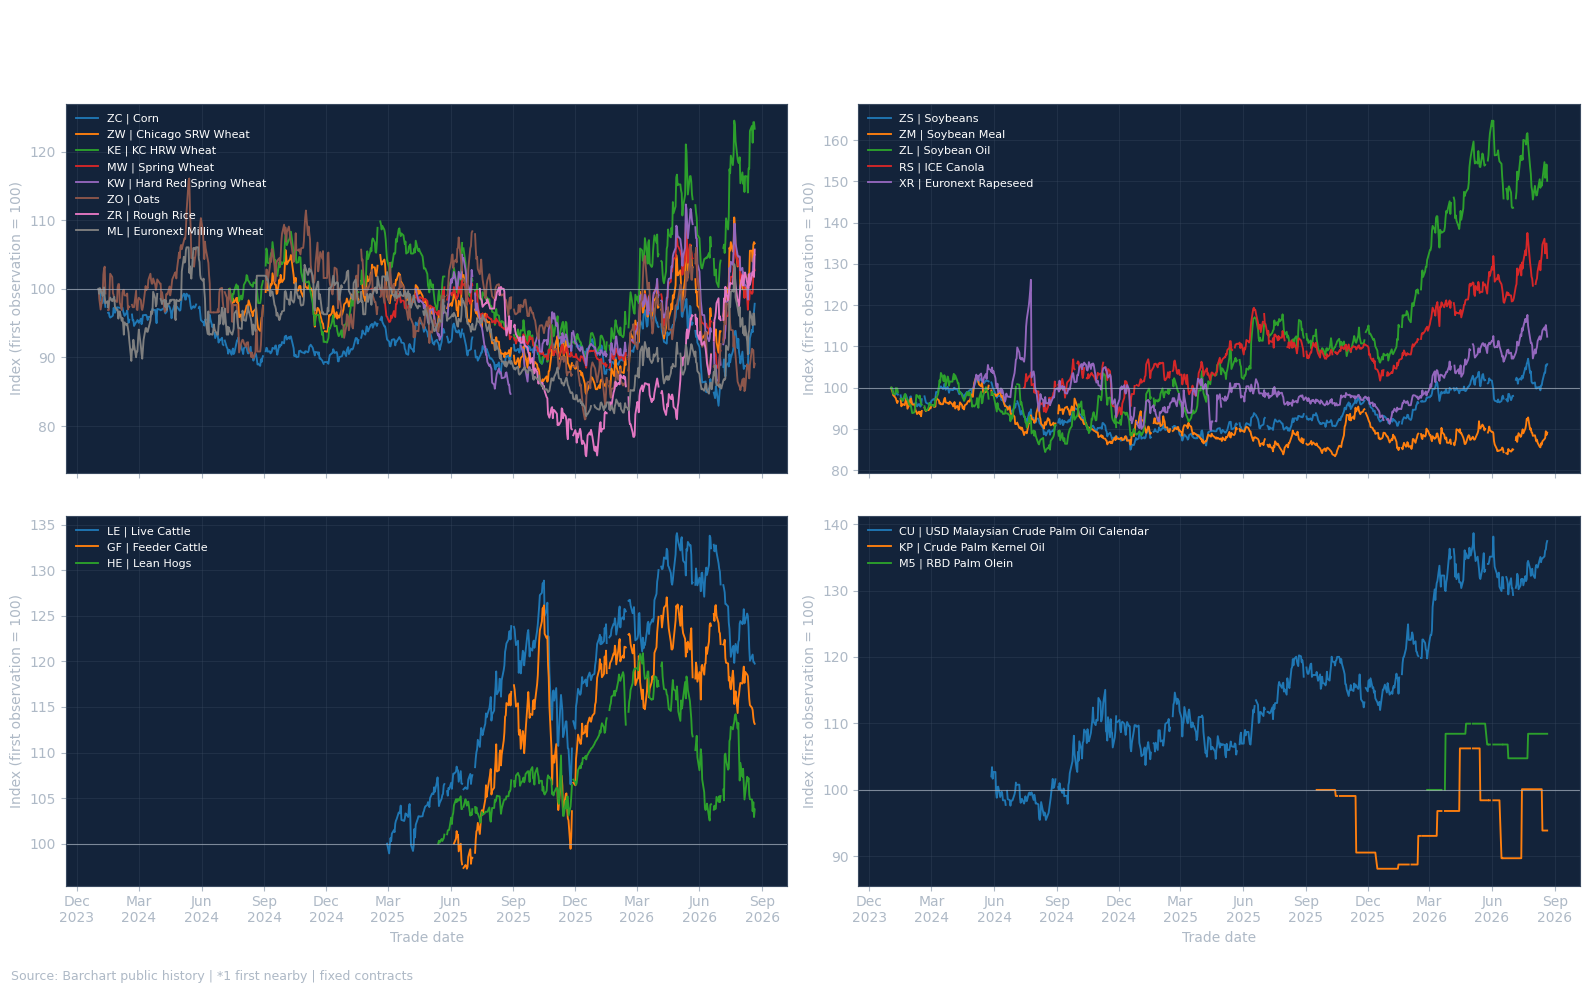

In [5]:
category_panels = [
    ("grains", "Grains"),
    ("oilseeds", "Oilseeds"),
    ("livestock", "Livestock"),
    ("vegetable_oils", "Vegetable oils"),
]
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.ravel()
colors = plt.get_cmap("tab10").colors

for axis, (category, title) in zip(axes, category_panels):
    axis.set_facecolor(navy)
    axis.grid(True, color="#3A4A60", alpha=0.35)
    axis.tick_params(colors=muted)
    for spine in axis.spines.values():
        spine.set_color("#3A4A60")
    roots = [
        root
        for root in indexed_history.columns
        if catalog_by_root[root].category == category
    ]
    for color_index, root in enumerate(roots):
        item = catalog_by_root[root]
        axis.plot(
            indexed_history.index,
            indexed_history[root],
            linewidth=1.35,
            color=colors[color_index % len(colors)],
            label=f"{root} | {item.name}",
        )
    axis.axhline(100, color=muted, linewidth=0.8, alpha=0.65)
    axis.set_title(title, loc="left", color="white", fontsize=13)
    axis.set_ylabel("Index (first observation = 100)", color=muted)
    axis.legend(frameon=False, labelcolor="white", fontsize=8, loc="best")

axes[2].set_xlabel("Trade date", color=muted)
axes[3].set_xlabel("Trade date", color=muted)
for axis in axes:
    axis.xaxis_date()
    axis.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

fig.suptitle(
    "Agricultural futures | current first-nearby contracts rebased to 100",
    color="white",
    fontsize=16,
    x=0.08,
    ha="left",
)
fig.text(
    0.01,
    0.01,
    "Source: Barchart public history | *1 first nearby | fixed contracts",
    color=muted,
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()



## 5. Illustrative agriculture composite

This is an analytical index, not an investment recommendation. Each market
group is first averaged across its available fixed contracts, then the
groups are combined with the visible weights below. The composite uses only
dates where at least one weighted group is available.



,weight,first_date,last_index
grains,0.35,2024-01-02,103.124015
oilseeds,0.35,2024-01-02,117.753490
livestock,0.20,2025-02-28,112.219783
vegetable_oils,0.10,2024-05-24,113.259982


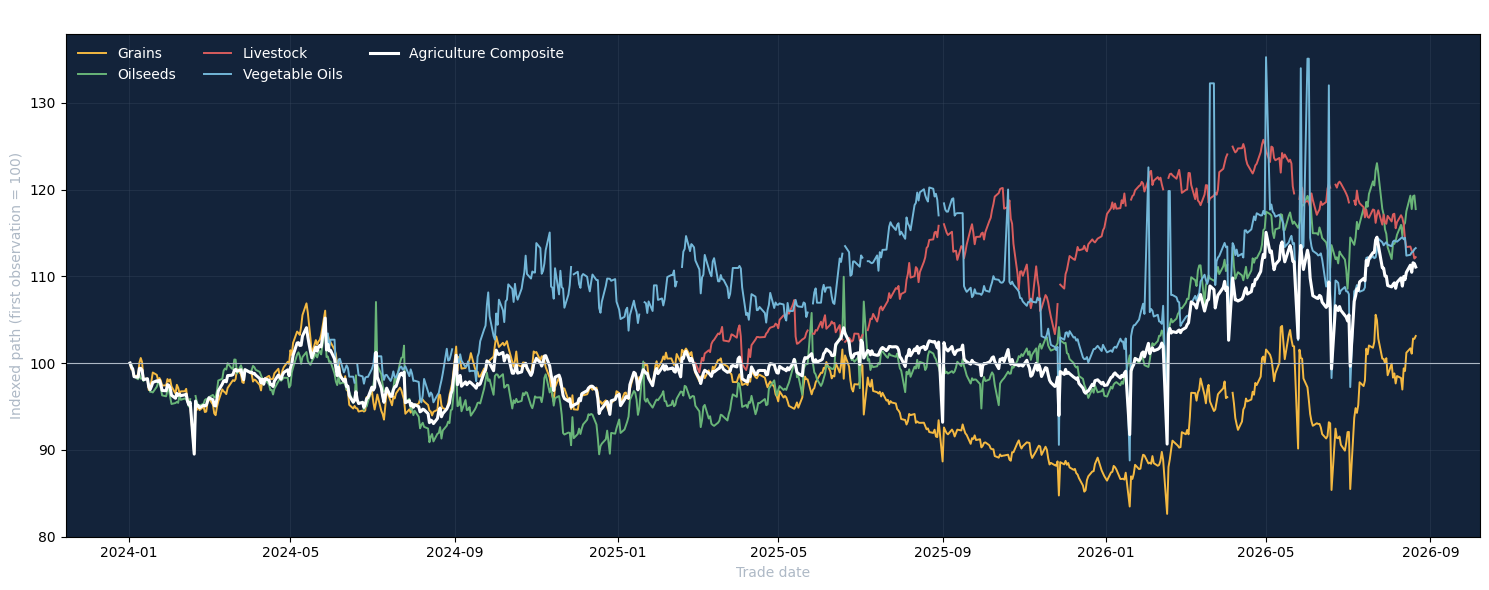

In [6]:
category_paths = {}
for category, _title in category_panels:
    roots = [
        root
        for root in indexed_history.columns
        if catalog_by_root[root].category == category
    ]
    if roots:
        category_paths[category] = indexed_history[roots].mean(axis=1)

category_index = pd.DataFrame(category_paths).sort_index()
available_weights = pd.Series(CATEGORY_WEIGHTS, dtype=float).reindex(
    category_index.columns
).fillna(0)
available_weights = available_weights / available_weights.sum()
weight_available = category_index.notna().mul(available_weights).sum(axis=1)
weighted_sum = category_index.mul(available_weights, axis=1).sum(axis=1, skipna=True)
category_index["Agriculture composite"] = weighted_sum.div(weight_available).where(
    weight_available > 0
)

category_summary = pd.DataFrame(
    {
        "weight": available_weights,
        "first_date": category_index[available_weights.index].apply(
            lambda series: series.first_valid_index().date()
            if series.first_valid_index() is not None
            else None
        ),
        "last_index": category_index[available_weights.index].apply(
            lambda series: series.dropna().iat[-1]
            if not series.dropna().empty
            else None
        ),
    }
)
display(category_summary)

fig, axis = plt.subplots(figsize=(15, 6))
axis.set_facecolor(navy)
for column, color in [
    ("grains", gold),
    ("oilseeds", green),
    ("livestock", red),
    ("vegetable_oils", sky),
    ("Agriculture composite", "white"),
]:
    if column in category_index:
        axis.plot(
            category_index.index,
            category_index[column],
            linewidth=2.2 if column == "Agriculture composite" else 1.4,
            color=color,
            label=column.replace("_", " ").title(),
        )
axis.axhline(100, color=muted, linewidth=0.8)
axis.set_title(
    "Illustrative agriculture group composite",
    loc="left",
    color="white",
    fontsize=16,
)
axis.set_ylabel("Indexed path (first observation = 100)", color=muted)
axis.set_xlabel("Trade date", color=muted)
axis.legend(frameon=False, labelcolor="white", ncol=3)
axis.grid(True, color="#3A4A60", alpha=0.35)
plt.tight_layout()
plt.show()



## Interpretation notes

- Different contracts have different units, currencies, liquidity, and
  trading calendars. The rebased chart is for direction and relative path
  inspection, not direct P&L.
- The notebook uses first-nearby shortcuts at run time and does not stitch
  historical contracts. Use the continuous-series builder when an explicit
  roll methodology is required.
- The catalog is curated around major grains, oilseeds, livestock, ICE
  Canada, Euronext Matif, and palm-oil-related roots; it is not a promise
  that every Barchart agricultural quote is included.
